# ML predictions for Pt+Ag dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

## Data preparation

In [10]:
# Load data for Pt and Ag
data_pt = pd.read_csv('/home/asikainen/Documents/Projects/Doped-TiO2/DFT-and-ML/Calculated-data/Data-for-ML.csv')
data_pt = data_pt.iloc[0:84]
data_pt = data_pt.iloc[:, 1:]

data_ag = data_ag = pd.read_csv('/home/asikainen/Documents/Projects/Doped-TiO2/DFT-and-ML/Calculated-data/Ag-doped/Ag-data-for-ML.csv')
data_ag = data_ag.iloc[0:14]
data_ag = data_ag.iloc[:, 1:]

data_all = pd.concat([data_pt, data_ag], axis=0)

In [11]:
# Add element label
data_all["element"] = ["Pt"] * len(data_pt) + ["Ag"] * len(data_ag)

# Map atomic number Z
Z_map = {"Pt": 78, "Ag": 47}
data_all["Z"] = data_all["element"].map(Z_map).astype(int)

Ag = data_all[data_all["Z"] == 47]
Pt = data_all[data_all["Z"] == 78]

In [12]:
# N used for splitting, removed later
selected_features = ['E_formation','N','CN_4Å_mean', 'dopant_Ti_distance_max', 'dopant_Ti_distance_min', 'E_fermi', 'q_Ti_min', 'q_Ti_max', 'E_vacuum_dopant_face','Z']
Pt = Pt[selected_features]
Ag = Ag[selected_features]

In [13]:
# Split Pt data
Pt_train, Pt_test = train_test_split(
    Pt,
    test_size=0.2,
    random_state=42
)

In [14]:
# Create Ag test set 
Ag_test = Ag.sample(n=5, random_state=42)
Ag_remaining = Ag.drop(Ag_test.index)

## ML predictions (Ag data progressively added to training)

In [20]:
# Kernel defined
kernel = (
    C(1.0, (1e-2, 1e2))
    * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e10))
    + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-10, 1e2))
)

# Models
model_dict = {
    "LR": LinearRegression(),
    "LASSO": Lasso(),
    "RLR": Ridge(),
    "EN": ElasticNet(),
    "RF": RandomForestRegressor(random_state=42),
    "GBR": GradientBoostingRegressor(random_state=42),
    "kNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "GPR": GaussianProcessRegressor(kernel=kernel, normalize_y=True)
}

# Hyperparameter grids
param_grids = {
    "LR": {},
    "LASSO": {"model__alpha": [0.001, 0.01, 0.1, 1]},
    "RLR": {"model__alpha": [0.001, 0.01, 0.1, 1]},
    "EN": {
        "model__alpha": [0.001, 0.01, 0.1, 1],
        "model__l1_ratio": [0.1, 0.5, 0.9]},
    "RF": {
        "model__n_estimators": [100, 300, 500],
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_split": [2, 5]},
    "GBR": {
        "model__n_estimators": [100, 300],
        "model__learning_rate": [0.01, 0.1],
        "model__max_depth": [2, 3, 5]},
    "kNN": {
        "model__n_neighbors": [2, 3, 5, 7],
        "model__weights": ["uniform", "distance"]},
    "SVR": {
        "model__C": [1, 10, 50, 100],
        "model__epsilon": [0.01, 0.05, 0.1],
        "model__gamma": ["scale", 0.01, 0.001]},
    "GPR": {
        "model__alpha": [1e-8, 1e-5, 1e-3]}
}

scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error"
}


results_list = []
predictions_list = []  
y_train_list = []      
y_test_list = [] 

# Number of Ag training data
n_ag_train_values = [0, 3, 6, 9]

# Predictions in a loop
for n_ag_train in n_ag_train_values:
    print(f"\nRunning iteration with n_ag_train = {n_ag_train}")
    
    if n_ag_train == 0:
        Ag_train = pd.DataFrame()  # Empty DataFrame for no Ag in training
    else:
        Ag_train = Ag_remaining.sample(n=n_ag_train, random_state=42)
    
    # Training and test sets
    T_train = pd.concat([Pt_train, Ag_train])
    T_test = pd.concat([Pt_test, Ag_test])
    T_train = T_train.drop(columns=['N'])
    T_test  = T_test.drop(columns=['N'])

    # Variables
    X = T_train.drop(columns=["E_formation"])
    y = T_train["E_formation"]
    X_test = T_test.drop(columns=["E_formation"])
    y_test = T_test["E_formation"]
    
    y = y.astype(float)
    y_test = y_test.astype(float)

    # ----------------------------------------------------------------------
    # Hyperparameter optimization + Cross-validation (CD) + Model evaluation
    
    results = {}
    best_models = {}
    predictions = {}
    
    for name, model in model_dict.items():
        if name in ["SVR", "kNN", "GPR"]:
            pipe = Pipeline([
                ("scaler", StandardScaler()),
                ("model", model)
            ])
        else:
            pipe = Pipeline([("model", model)])
        
        gs = GridSearchCV(
            estimator=pipe,
            param_grid=param_grids[name],
            scoring=scoring,
            refit="r2",
            cv=5,
            n_jobs=-1,
            return_train_score=True
        )
        
        gs.fit(X, y)
        
        best_models[name] = gs.best_estimator_
        
        # CV metrics
        cv_r2 = gs.cv_results_["mean_test_r2"][gs.best_index_]
        cv_rmse = -gs.cv_results_["mean_test_rmse"][gs.best_index_]
        cv_mae = -gs.cv_results_["mean_test_mae"][gs.best_index_]
        
        # Train and test metrics
        y_train_pred = gs.predict(X)
        y_test_pred = gs.predict(X_test)
        
        train_r2 = r2_score(y, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        mse = mean_squared_error(y_test, y_test_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_test_pred)
        
        # Separate Pt and Ag
        mask_pt = X_test['Z'] == 78
        mask_ag = X_test['Z'] == 47

        #Per-element metrics
        # Pt 
        rmse_pt = np.sqrt(mean_squared_error(y_test[mask_pt], y_test_pred[mask_pt]))
        mae_pt = mean_absolute_error(y_test[mask_pt], y_test_pred[mask_pt])
        r2_pt = r2_score(y_test[mask_pt], y_test_pred[mask_pt])
        # Ag 
        rmse_ag = np.sqrt(mean_squared_error(y_test[mask_ag], y_test_pred[mask_ag]))
        mae_ag = mean_absolute_error(y_test[mask_ag], y_test_pred[mask_ag])
        r2_ag = r2_score(y_test[mask_ag], y_test_pred[mask_ag])
        
        results[name] = {
            "Training R2": train_r2,
            "CV R2": cv_r2,
            "CV RMSE": cv_rmse,
            "CV MAE": cv_mae,
            "Test R2": test_r2,
            "Test RMSE": rmse,
            "Test MAE": mae,
            "Pt R2": r2_pt,
            "Pt RMSE": rmse_pt,
            "Pt MAE": mae_pt,
            "Ag R2": r2_ag,
            "Ag RMSE": rmse_ag,
            "Ag MAE": mae_ag,
        }
        
        predictions[name] = {
            'train': y_train_pred,
            'test': y_test_pred
        }
    
    # Store data 
    results_df = pd.DataFrame(results).T
    results_list.append(results_df) 
    predictions_list.append(predictions)
    y_train_list.append(y)
    y_test_list.append(y_test)

# Show results
for i, n_ag_train in enumerate(n_ag_train_values):
    print(f"\nResults Table for n_ag_train = {n_ag_train}:")
    print(results_list[i])


Running iteration with n_ag_train = 0

Running iteration with n_ag_train = 3

Running iteration with n_ag_train = 6

Running iteration with n_ag_train = 9

Results Table for n_ag_train = 0:
       Training R2     CV R2   CV RMSE    CV MAE   Test R2  Test RMSE  \
LR        0.956153  0.890819  0.029459  0.020340 -0.553472   0.412632   
LASSO     0.927881  0.886136  0.028530  0.019597 -0.168922   0.357935   
RLR       0.936087  0.903903  0.025827  0.018437 -0.187560   0.360777   
EN        0.923040  0.890157  0.027865  0.019586 -0.186692   0.360645   
RF        0.989732  0.933915  0.023456  0.019019 -0.233766   0.367729   
GBR       0.997763  0.945246  0.020651  0.015734 -0.288792   0.375840   
kNN       1.000000  0.872320  0.031847  0.022964 -0.485021   0.403439   
SVR       0.992688  0.938588  0.023108  0.015694 -0.328036   0.381519   
GPR       0.988167  0.915197  0.026024  0.015975 -0.238816   0.368481   

       Test MAE     Pt R2   Pt RMSE    Pt MAE      Ag R2   Ag RMSE    Ag MAE  

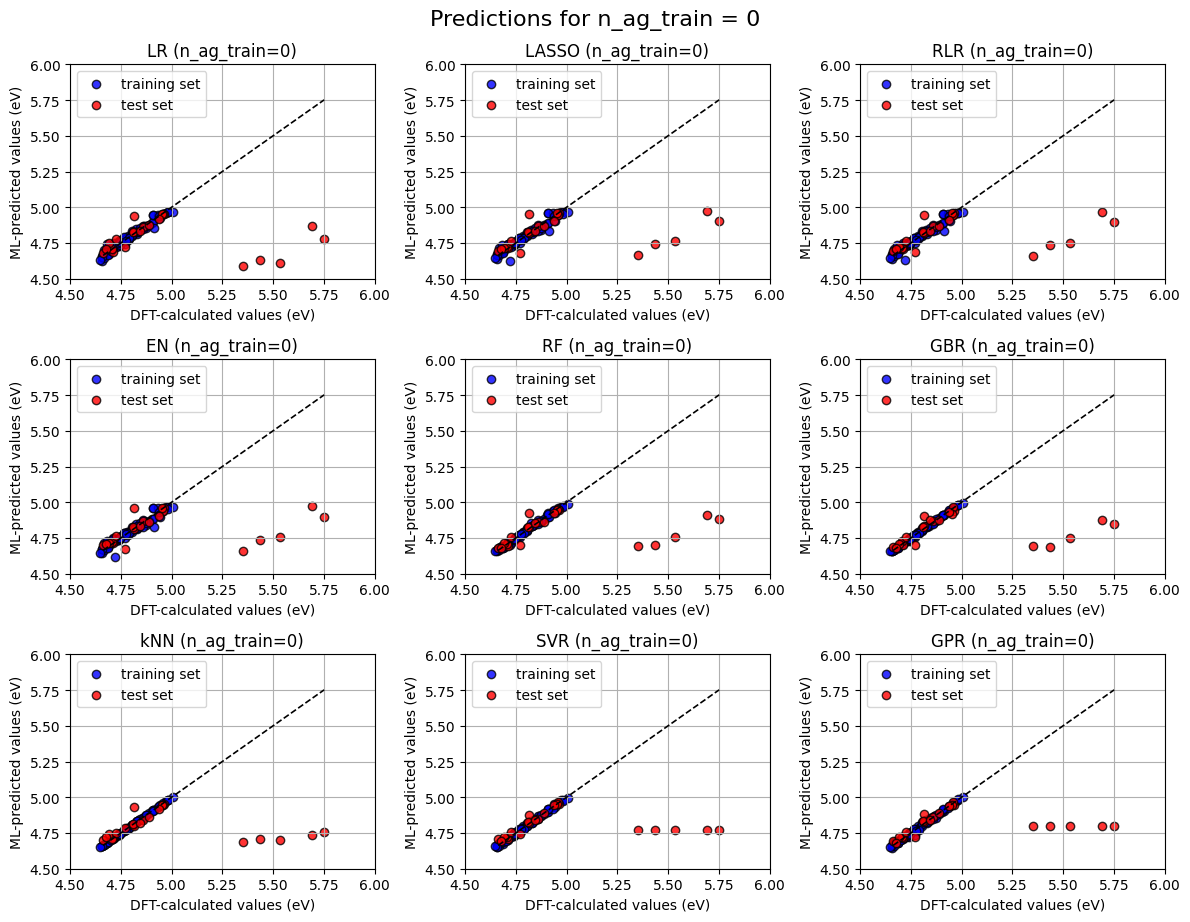

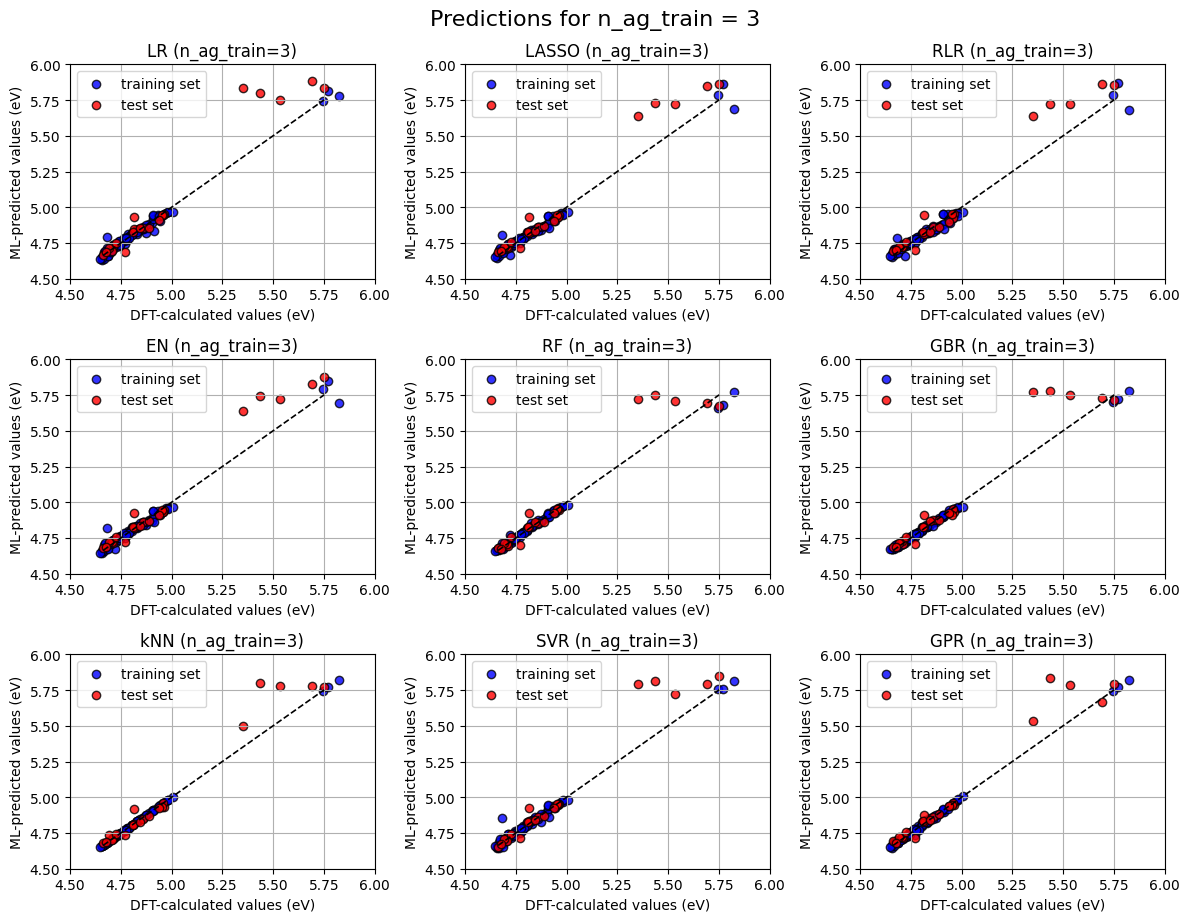

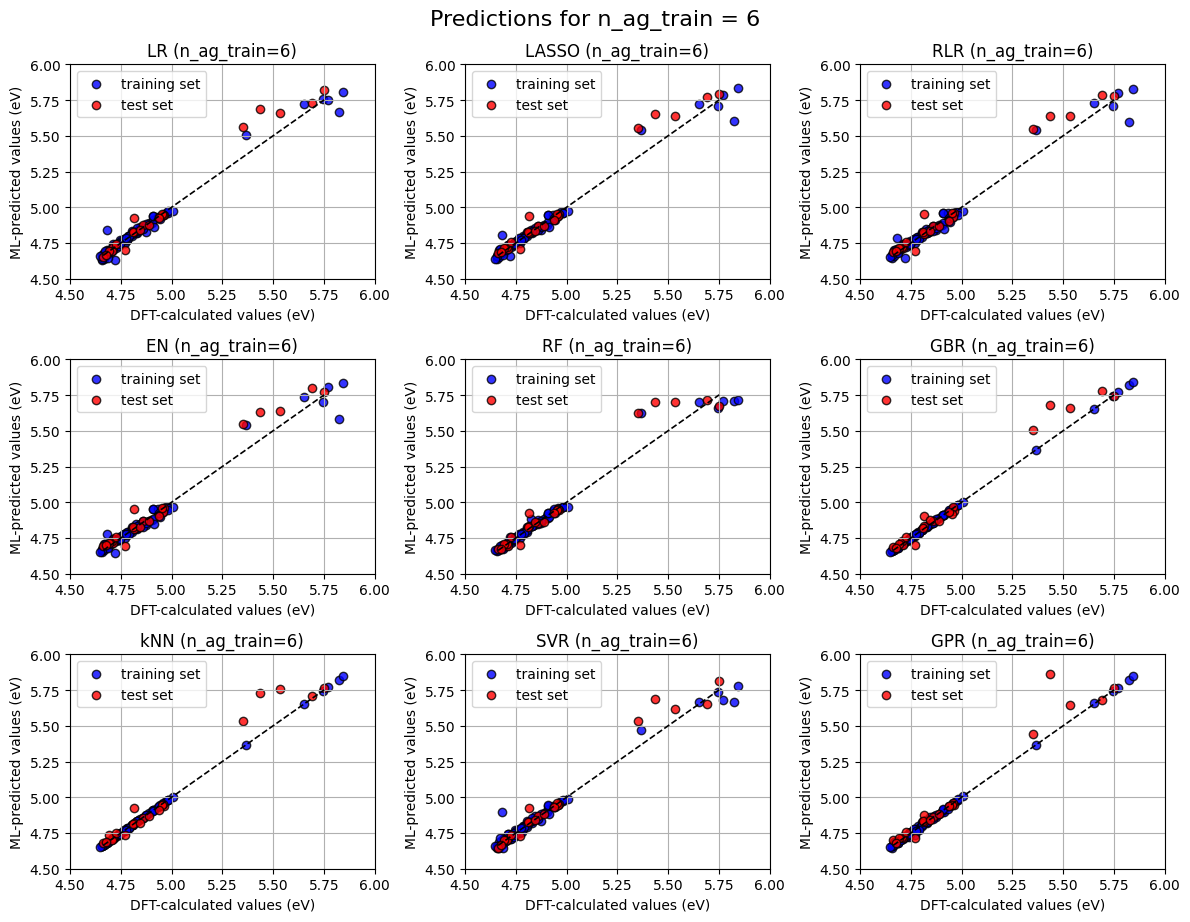

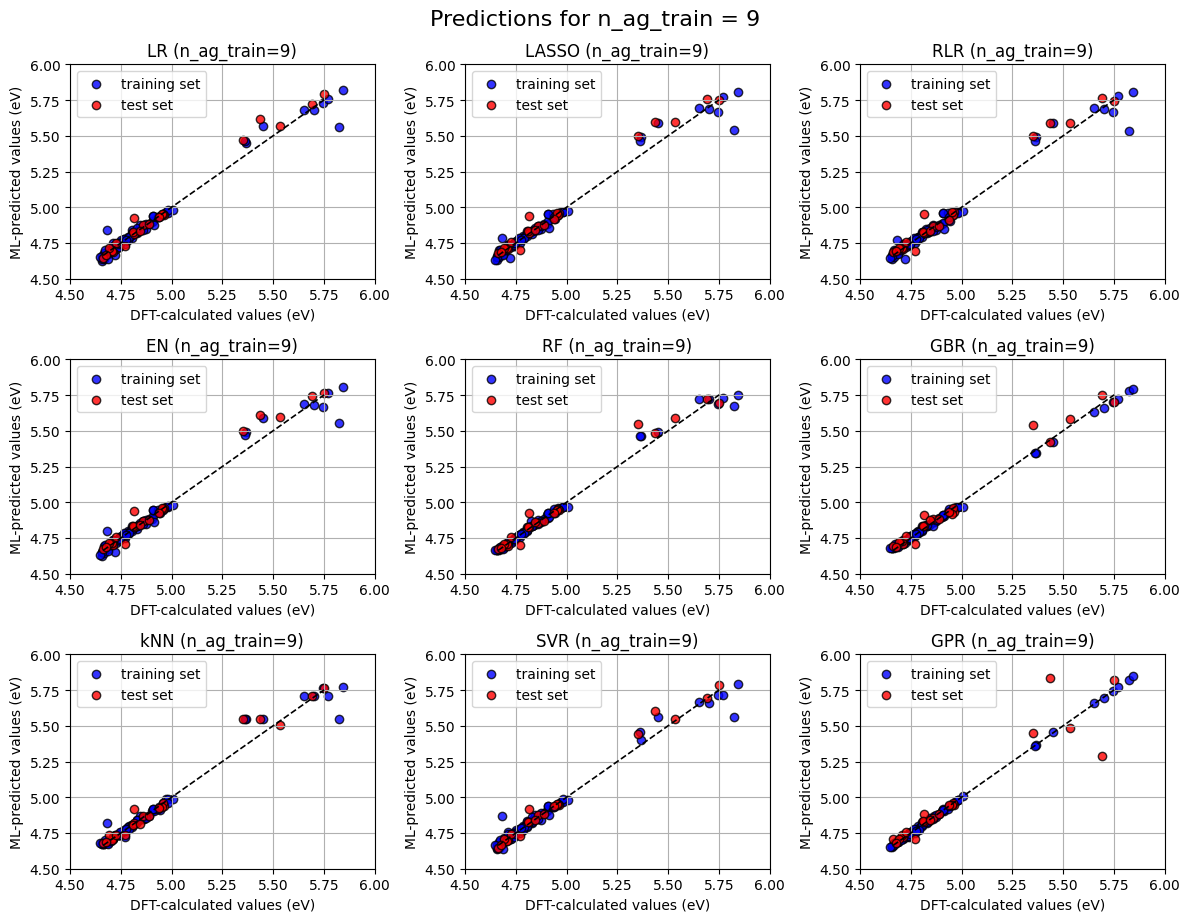

In [24]:
# Scatter plots: calculated vs. predicted values 
for idx, n_ag_train in enumerate(n_ag_train_values):
    predictions = predictions_list[idx]
    y = y_train_list[idx]  
    y_test = y_test_list[idx]  
    
    # Figure for each n_ag_train
    fig, axes = plt.subplots(3, 3, figsize=(12, 9))
    axes = axes.flatten()
    
    for i, (name, preds) in enumerate(predictions.items()):
        ax = axes[i]
        y_train_pred = preds['train']  
        y_test_pred = preds['test']    
        
        # train (blue) and test (red)
        ax.scatter(y, y_train_pred, alpha=0.8, color="blue", edgecolors="black")
        ax.scatter(y_test, y_test_pred, alpha=0.8, color="red", edgecolors="black")
        # Perfect prediction
        ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], "--", color="black", linewidth=1.2)
        ax.set_title(f"{name} (n_ag_train={n_ag_train})")
        ax.set_xlabel("DFT-calculated values (eV)")
        ax.set_ylabel("ML-predicted values (eV)")
        ax.set_ylim(4.5, 6)
        ax.set_xlim(4.5, 6)
        ax.grid(True)
        ax.legend(['training set', 'test set'], loc='upper left')
    
    plt.tight_layout()
    plt.suptitle(f"Predictions for n_ag_train = {n_ag_train}", fontsize=16, y=1.02)  # Overall title
    plt.show()